<a href="https://colab.research.google.com/github/Sidnaik04/AI-Engineering/blob/main/Sampling_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sampling Techniques

### Log Probabilities:

In [ ]:
import math

original_prob = 0.7

logprob = math.log(original_prob)
prob = math.exp(logprob)

print(f"Original probability: {original_prob}")
print(f"Log probability: {logprob}")
print(f"Reconstructed probability: {prob}")

Original probability: 0.7
Log probability: -0.35667494393873245
Reconstructed probability: 0.7


### Greedy Sampling

In [ ]:
def greedy_sample(logprobs):
  return max(logprobs, key=lambda item: item['prob'])

In [ ]:
next_token_logprobs = [
    {"token": "Apple", "prob": 0.6},
    {"token": "Banana", "prob": 0.3},
    {"token": "Cherry", "prob": 0.1},
]

print(greedy_sample(next_token_logprobs))

{'token': 'Apple', 'prob': 0.6}


### Logits and Softmax

In [1]:
# NumPy Implementation

import numpy as np

def softmax(logits: np.ndarray, temperature: float = 1.0)->np.ndarray:
  # divide logits by temperature
  scaled_logits = logits/temperature

  # Subtract max for numerical stability (prevents overflow)
  stable_logits = scaled_logits - np.max(scaled_logits)

  # compute exponentials
  exp_logits = np.exp(stable_logits)

  # normalize to form probability distribution
  probabilities = exp_logits / np.sum(exp_logits)

  return probabilities

In [2]:
# Example Logits (e.g., across 3 vocabulary tokens: "cat", "dog", "car")
logits = np.array([3.0, 1.0, -0.5])

In [3]:
probs = softmax(logits, temperature=1.0)
print(f"Probabilities (T=1.0) : {probs}")
print(f"Sum of Probabilities  : {np.sum(probs):.1f}")

Probabilities (T=1.0) : [0.85797681 0.11611453 0.02590865]
Sum of Probabilities  : 1.0


In [4]:
probs_low_temp = softmax(logits, temperature=0.5)
print(f"Probabilities (T=0.5) : {probs_low_temp}")

Probabilities (T=0.5) : [9.81135202e-01 1.79701181e-02 8.94679497e-04]


---

In [5]:
# Pytorch implementation

import torch
import torch.nn.functional as F

# Simulate LLM output for a vocabulary of size 5
# Logits shape: [batch_size=1, sequence_length=1, vocab_size=5]
vocab_logits = torch.tensor([[[2.1, 0.4, -1.2, 5.0, 1.8]]])

# Compute probabilities along the vocabulary dimension (dim=-1)
vocab_probs = F.softmax(vocab_logits, dim=-1)

tokens = ["the", "a", "an", "cat", "dog"]
token_prob_map = dict(zip(tokens, vocab_probs.squeeze().tolist()))

print("Probability distribution over vocabulary:")
for token, prob in token_prob_map.items():
    print(f"  '{token}': {prob:.4f}")

# Extract top token (Greedy prediction)
top_token_id = torch.argmax(vocab_probs, dim=-1).item()
print(f"\nTop predicted token: '{tokens[top_token_id]}'")

Probability distribution over vocabulary:
  'the': 0.0497
  'a': 0.0091
  'an': 0.0018
  'cat': 0.9026
  'dog': 0.0368

Top predicted token: 'cat'


### Temperature Sampling

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

inputs = tokenizer("Explain AI in simple terms", return_tensors="pt")

output = model.generate(
    **inputs,
    max_length=50,
    temperature=0.7,
    do_sample=True
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Explain AI in simple terms by using AI to automate systems and tools. For example, if an agent was given a list of all possible candidates for a job, the AI would ask questions about those candidates and ask the agents what they would do if


In [11]:
# using pytorch

import torch
import torch.nn.functional as F

logits = torch.tensor([4.0, 2.0, 1.0, 0.1])
tokens = ["cat", "dog", "car", "banana"]

def inspect_temp(logits, temp):
  if temp == 0:
    # T=0 collapse to ArgMax
    probs = torch.zeros_like(logits)
    probs[torch.argmax(logits)] = 1.0

  else:
    probs = F.softmax(logits / temp, dim=-1)

  return probs

In [12]:
print("T = 0.0 (Greedy):", inspect_temp(logits, 0.0).tolist())
print("T = 0.2 (Sharp) :", [round(p, 3) for p in inspect_temp(logits, 0.2).tolist()])
print("T = 1.0 (Base)  :", [round(p, 3) for p in inspect_temp(logits, 1.0).tolist()])
print("T = 2.0 (Flat)  :", [round(p, 3) for p in inspect_temp(logits, 2.0).tolist()])

T = 0.0 (Greedy): [1.0, 0.0, 0.0, 0.0]
T = 0.2 (Sharp) : [1.0, 0.0, 0.0, 0.0]
T = 1.0 (Base)  : [0.83, 0.112, 0.041, 0.017]
T = 2.0 (Flat)  : [0.577, 0.212, 0.129, 0.082]


Temperature = 0.1, sampled: nice
Temperature = 0.5, sampled: nice
Temperature = 1.0, sampled: nice
Temperature = 3.0, sampled: cloudy
Temperature = 10.0, sampled: hot


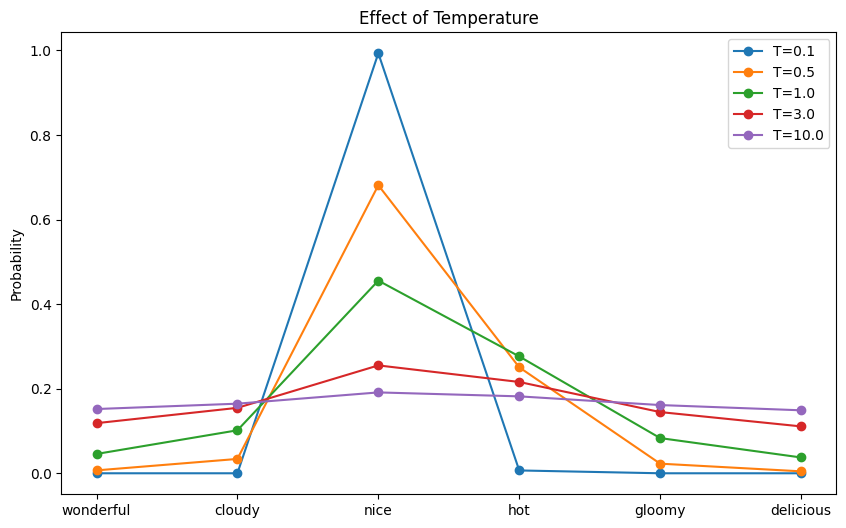

In [19]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

vocab = ["wonderful", "cloudy", "nice", "hot", "gloomy", "delicious"]
logits = torch.tensor([1.2, 2.0, 3.5, 3.0, 1.8, 1.0]) # (vocab_size,)
scores = logits.unsqueeze(0) # (1, vocab_size)
temperatures = [0.1, 0.5, 1.0, 3.0, 10.0]

fig, ax = plt.subplots(figsize=(10,6))
for temp in temperatures:
  # Apply temperature scaling
  scores_processed = scores / temp

  # convert probabilities
  probs = F.softmax(scores_processed, dim=-1)[0]

  # sample from the distribution
  sampled_idx = torch.multinomial(probs, num_samples=1).item()

  print(f"Temperature = {temp}, sampled: {vocab[sampled_idx]}")

  # Plot the probability distribution
  ax.plot(vocab, probs.numpy(), marker='o', label=f"T={temp}")

ax.set_title("Effect of Temperature")
ax.set_ylabel("Probability")
ax.legend()
plt.show()

---

### Top-k Sampling

In [20]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

inputs = tokenizer("Explain AI in simple terms", return_tensors="pt")

output = model.generate(
    **inputs,
    max_length=50,
    top_k=50,
    do_sample=True
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Explain AI in simple terms with the concept behind the HMD's camera.

On board this new HMD we are introduced to our first test case for these cameras.

This is what you get for asking:

An H


In [21]:
# pytorch implementation

import torch
import torch.nn.functional as F

def top_k_sampling(logits: torch.Tensor, k: int, temperature: float = 1.0) -> torch.Tensor:
  # 1. Apply temperature
  scaled_logits = logits / temperature

  # 2. Identify values below the top-k threshold
  top_k_values, _ = torch.topk(scaled_logits, k)
  min_top_k_val = top_k_values[-1] # the kth largest value

  # 3. Mask out all logits below min_top_k_val with -inifinity
  filtered_logits = torch.where(
      scaled_logits < min_top_k_val,
      torch.tensor(float('-inf')),
      scaled_logits
  )

  # 4. Softmax automatically re-normalizes masked logits to a valid distribution
  probs = F.softmax(filtered_logits, dim=-1)

  # 5. Sample token index from filtered distribution
  next_token_id = torch.multinomial(probs, num_samples=1)

  return next_token_id

In [22]:
# Example Logits (Vocab size = 5)
logits = torch.tensor([2.0, 4.0, 0.5, -1.0, 3.5])
sampled_token = top_k_sampling(logits, k=2, temperature=0.8)
print("Sampled Token ID:", sampled_token.item())

Sampled Token ID: 1


Top-k = 1, sampled: nice
Top-k = 2, sampled: hot
Top-k = 3, sampled: nice
Top-k = 6, sampled: delicious


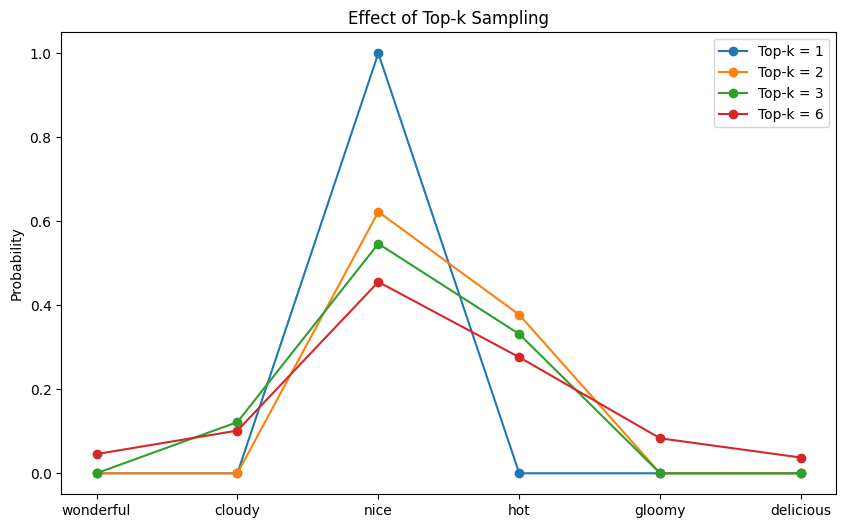

In [30]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

vocab = ["wonderful", "cloudy", "nice", "hot", "gloomy", "delicious"]
logits = torch.tensor([1.2, 2.0, 3.5, 3.0, 1.8, 1.0]) # (vocab_size,)
scores = logits.unsqueeze(0) # (batch, vocab_size)
k_candidates = [1, 2, 3, 6]

fig, ax = plt.subplots(figsize=(10, 6))
for top_k in k_candidates:
    # 1. get the top-k logits
    topk_values = torch.topk(scores, top_k)[0]
    # 2. threshold = smallest logit inside the top-k set
    threshold = topk_values[..., -1, None] # (..., 1)
    # 3. mask all logits below the threshold to -inf
    indices_to_remove = scores < threshold
    filtered_scores = scores.masked_fill(indices_to_remove, -float("inf"))
    # convert to probabilities, those with -inf logits will get zero probability
    probs = F.softmax(filtered_scores, dim=-1)[0]
    # sample from the filtered distribution
    sampled_idx = torch.multinomial(probs, num_samples=1).item()
    print(f"Top-k = {top_k}, sampled: {vocab[sampled_idx]}")
    # Plot the probability distribution
    ax.plot(vocab, probs.numpy(), marker='o', label=f"Top-k = {top_k}")

ax.set_title("Effect of Top-k Sampling")
ax.set_ylabel("Probability")
ax.legend()
plt.show()